# Carga de librerías y archivos

In [1]:
from pathlib import Path
from math import comb, exp, factorial
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

In [3]:
#Lista de archivos requeridos

ARCHIVOS_REQUERIDOS = [
    'conectividad_aerea_cabotaje.csv',
    'conectividad_aerea_internacional.csv',
    '202512-informe-ministerio-actualizado-dic-final.csv',
    '202604-informe-ministerio.csv',
    'failbondi-2026-05-20-dump.json',
]

#Búsqueda automática de los datasets
def resolver_data_dir():
    #Lista de carpetas candidatas
    candidatos = [
        Path.cwd() / 'datasets',
        Path.cwd(),
        Path.cwd().parent / 'datasets', 
        Path.cwd() / '4' / 'datasets',
        Path('/content') / 'datasets',
        Path('/content'),
        Path('/content/4') / 'datasets',
        Path('/content/drive/MyDrive/Matematica IV/4') / 'datasets',
        Path('/content/drive/MyDrive/Matematica_IV/4') / 'datasets',
    ]

    for data_dir in candidatos:
        if data_dir.exists() and all((data_dir / archivo).exists() for archivo in ARCHIVOS_REQUERIDOS):
            return data_dir

    raise FileNotFoundError(
        'No se encontraron todos los datasets.'
    )

#Ruta a los dataset
DATA_DIR = resolver_data_dir()

#Ruta a la carpeta principal del proyecto
BASE_DIR = DATA_DIR.parent if DATA_DIR.name == 'datasets' else DATA_DIR

#Obtener los nombres de los archivos
archivos = sorted(p.name for p in DATA_DIR.iterdir())
print('Carpeta de datasets:', DATA_DIR)
print('Datasets encontrados:')
for nombre in archivos:
    print('-', nombre)


Carpeta de datasets: /home/charita/Documentos/UNRN/MATE4/MateIV_Transporte_Publico/datasets
Datasets encontrados:
- 202512-informe-ministerio-actualizado-dic-final.csv
- 202604-informe-ministerio.csv
- conectividad_aerea_cabotaje.csv
- conectividad_aerea_internacional.csv
- failbondi-2026-05-20-dump.json


# Carga e inspección de datasets
Despues cargamos los movimientos aeroportuarios informados por ANAC.

In [4]:
DIAS = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

#Usamos on_bad_lines para que panda saltee las filas que tienen errores.
# y warn es para que nos informe cuales salteo.
def leer_anac(nombre_archivo):
    df = pd.read_csv(DATA_DIR / nombre_archivo, sep=';', decimal=',', on_bad_lines='warn')
    df.columns = df.columns.str.strip()

    for columna in ['Pasajeros', 'PAX']:
        df[columna] = pd.to_numeric(df[columna], errors='coerce')

    df['Fecha UTC'] = pd.to_datetime(
        df['Fecha UTC'],
        dayfirst=True,
        errors='coerce'
    )

    df['anio'] = df['Fecha UTC'].dt.year
    df['mes'] = df['Fecha UTC'].dt.month

    df['dia_semana'] = (
        df['Fecha UTC']
        .dt.day_name()
        .map(DIAS)
    )

    return df

anac_2025 = leer_anac('202512-informe-ministerio-actualizado-dic-final.csv')
anac_2026 = leer_anac('202604-informe-ministerio.csv')
anac = pd.concat([anac_2025, anac_2026], ignore_index=True)

print('Filas ANAC 2025:', len(anac_2025))
print('Filas ANAC 2026:', len(anac_2026))
print('Filas ANAC totales:', len(anac))



Filas ANAC 2025: 597784
Filas ANAC 2026: 197320
Filas ANAC totales: 795104


In [5]:
#INFORMACIÓN DEL DATASET DE MOVIMIENTOS DE ANAC


print('-' * 100)
print("CANTIDAD DE FILAS DEL DATASET DE MOVIMIENTOS DE ANAC")
print('-' * 100)
print()
#Cantidad de filas del dataset
print('Filas cabotaje:', len(anac))
print('Filas internacional:', len(anac))
print('Filas totales:', len(anac))

#Conocer el rango temporal del dataset

fecha_inicio = anac['Fecha UTC'].min()
fecha_fin = anac['Fecha UTC'].max()

print()
print('-' * 100)
print("RANGO TEMPORAL DEL DATASET DE MOVIMIENTOS DE ANAC")
print('-' * 100)

print()
print("Fecha de inicio del dataset:", fecha_inicio.strftime('%d/%m/%Y'))
print("Fecha fin del dataset:", fecha_fin.strftime('%d/%m/%Y'))


print()
print('-' * 100)
print("INFORMACIÓN DEL DATASET DE MOVIMIENTOS DE ANAC")
print('-' * 100)
print()
#Obtener información del dataset
anac.info()

----------------------------------------------------------------------------------------------------
CANTIDAD DE FILAS DEL DATASET DE MOVIMIENTOS DE ANAC
----------------------------------------------------------------------------------------------------

Filas cabotaje: 795104
Filas internacional: 795104
Filas totales: 795104

----------------------------------------------------------------------------------------------------
RANGO TEMPORAL DEL DATASET DE MOVIMIENTOS DE ANAC
----------------------------------------------------------------------------------------------------

Fecha de inicio del dataset: 01/01/2025
Fecha fin del dataset: 30/04/2026

----------------------------------------------------------------------------------------------------
INFORMACIÓN DEL DATASET DE MOVIMIENTOS DE ANAC
----------------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 795104 entries, 0 to 795103
Data columns (

In [6]:
display(anac.head())

,Fecha UTC,Hora UTC,Clase de Vuelo (todos los vuelos),Clasificación Vuelo,Tipo de Movimiento,Aeropuerto,Origen / Destino,Aerolinea Nombre,Aeronave,Pasajeros,PAX,Calidad dato,anio,mes,dia_semana
0,2025-01-01,0:00,Regular,Doméstico,Aterrizaje,BAR,EZE,FB LÍNEAS AÉREAS - FLYBONDI,BO-737-8Q8,167.0,83.5,DEFINITIVO,2025,1,Miércoles
1,2025-01-01,0:03,Regular,Internacional,Despegue,EZE,KATL,DELTA AIRLINES,0,281.0,281.0,DEFINITIVO,2025,1,Miércoles
2,2025-01-01,0:06,Regular,Doméstico,Aterrizaje,SAL,NEU,JETSMART AIRLINES S.A.,AIB-A320-232,174.0,87.0,DEFINITIVO,2025,1,Miércoles
3,2025-01-01,0:07,Regular,Doméstico,Aterrizaje,CBA,BAR,FB LÍNEAS AÉREAS - FLYBONDI,BO-737-8U3,83.0,41.5,DEFINITIVO,2025,1,Miércoles
4,2025-01-01,0:07,Regular,Internacional,Despegue,AER,SCEL,LATAM AIRLINES GROUP S.A.(exLAN AIRLINE),0,162.0,162.0,DEFINITIVO,2025,1,Miércoles


In [7]:
#El dataset 202512-informe-ministerio-actualizado-dic-final.csv' tiene errores en sus filas
#Función para determinar en cuantas filas tiene errores.

archivo = DATA_DIR / '202512-informe-ministerio-actualizado-dic-final.csv'

# Total de filas en el archivo
with open(archivo, encoding='utf-8') as f:
    total_lineas = sum(1 for _ in f)

# Filas válidas (las que Pandas intenta leer)
df = pd.read_csv(
    archivo,
    sep=';',
    decimal=',',
    engine='python',
    on_bad_lines='skip'   # saltea las filas con errores.
)

filas_validas = len(df)
filas_ignoradas = total_lineas - filas_validas

print("Total de líneas:", total_lineas)
print("Filas cargadas:", filas_validas)
print("Filas ignoradas:", filas_ignoradas)

Total de líneas: 597785
Filas cargadas: 597784
Filas ignoradas: 1


# Limpieza y preparación de datos


In [9]:
resumen_datasets = pd.DataFrame({
    'dataset': ['ANAC'],
    'filas': [len(anac)],
    'columnas': [anac.shape[1]],
})
display(resumen_datasets)



print('Nulos principales en ANAC:')
display(anac[['Fecha UTC', 'Clasificación Vuelo', 'Tipo de Movimiento', 'Pasajeros', 'PAX']].isna().sum())
print()



,dataset,filas,columnas
0,ANAC,795104,15


Nulos principales en ANAC:


Fecha UTC              0
Clasificación Vuelo    0
Tipo de Movimiento     0
Pasajeros              0
PAX                    0
dtype: int64

# Análisis estadístico descriptivo


    hora        PAX
0      0  2333315.0
1      1  1929939.5
2      2  1747626.0
3      3  1586767.5
4      4  1025164.0
5      5   834470.5
6      6   867181.5
7      7  1136146.0
8      8  1330770.0
9      9  1533708.5
10    10  2384741.0
11    11  2275264.5
12    12  2191733.0
13    13  2233769.5
14    14  2104883.5
15    15  2276319.0
16    16  2473471.5
17    17  2245998.0
18    18  2080751.0
19    19  2142323.0
20    20  2150245.0
21    21  2266620.0
22    22  2247149.0
23    23  2257520.0
Mayor demanda: 16:00 hs - 2,473,472 PAX
Menor demanda: 5:00 hs - 834,470 PAX


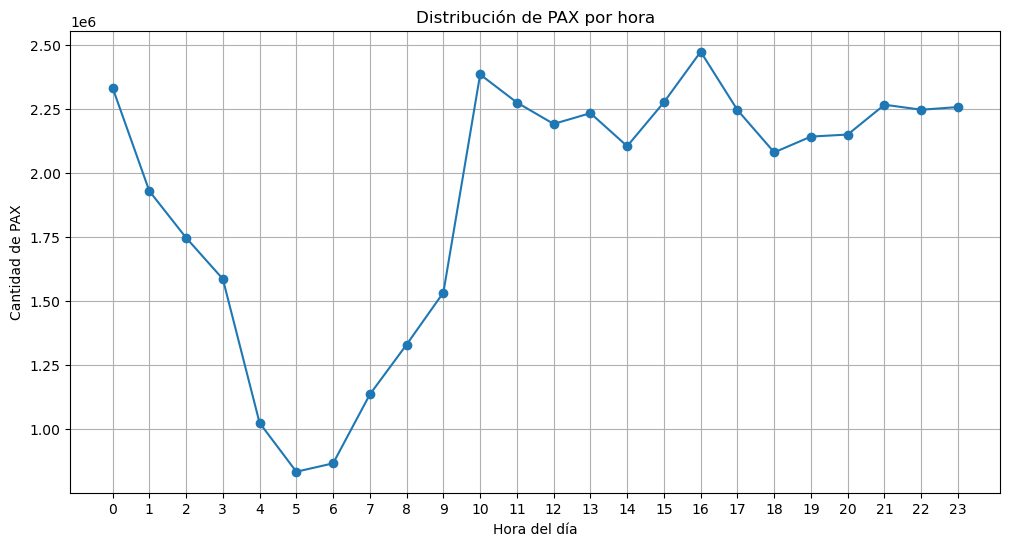

In [10]:
#Cuál es el rango horario con más pasajeros y con menos?

# Hora entera (0-23)
hora = pd.to_datetime(anac['Hora UTC'], format='%H:%M').dt.hour

# PAX por hora
pax_por_hora = (
    anac.groupby(hora)['PAX']
        .sum()
        .reset_index()
)

pax_por_hora.columns = ['hora', 'PAX']

print(pax_por_hora)

# Hora de mayor y menor demanda
hora_max = pax_por_hora.loc[pax_por_hora['PAX'].idxmax()]
hora_min = pax_por_hora.loc[pax_por_hora['PAX'].idxmin()]

print(f"Mayor demanda: {int(hora_max['hora'])}:00 hs - {hora_max['PAX']:,.0f} PAX")
print(f"Menor demanda: {int(hora_min['hora'])}:00 hs - {hora_min['PAX']:,.0f} PAX")

# Gráfico
plt.figure(figsize=(12,6))
plt.plot(
    pax_por_hora['hora'],
    pax_por_hora['PAX'],
    marker='o'
)

plt.xticks(range(24))
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de PAX')
plt.title('Distribución de PAX por hora')
plt.grid(True)
plt.show()

  dia_semana        PAX
0      Lunes  6773239.0
1     Martes  6175536.5
2  Miércoles  6325467.0
3     Jueves  6391630.0
4    Viernes  6571352.0
5     Sábado  6803175.5
6    Domingo  6615476.5

Mayor demanda: Sábado - 6,803,176 PAX
Menor demanda: Martes - 6,175,536 PAX


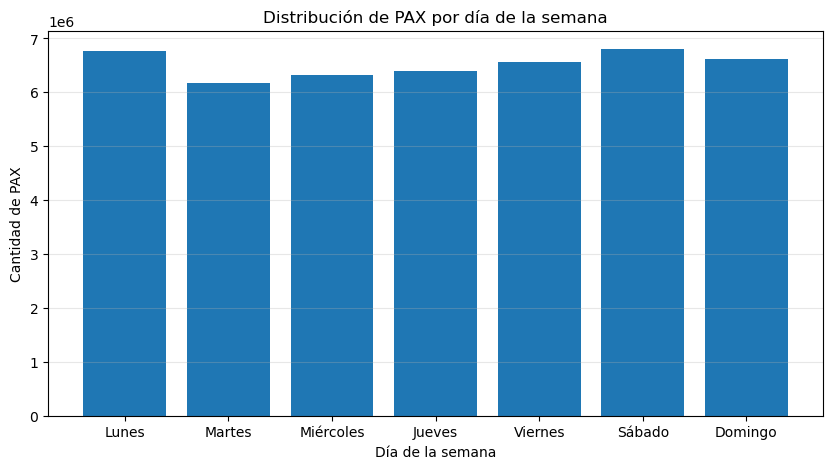

In [11]:
#Qué dia de la semana transporte más pasajeros? y Cuál menos?
orden_dias = [
    'Lunes', 'Martes', 'Miércoles',
    'Jueves', 'Viernes', 'Sábado', 'Domingo'
]

# PAX por día de la semana
pax_por_dia = (
    anac.groupby('dia_semana')['PAX']
        .sum()
        .reindex(orden_dias)
        .reset_index()
)

print(pax_por_dia)

# Día de mayor y menor demanda
dia_max = pax_por_dia.loc[pax_por_dia['PAX'].idxmax()]
dia_min = pax_por_dia.loc[pax_por_dia['PAX'].idxmin()]

print(f"\nMayor demanda: {dia_max['dia_semana']} - {dia_max['PAX']:,.0f} PAX")
print(f"Menor demanda: {dia_min['dia_semana']} - {dia_min['PAX']:,.0f} PAX")

# Gráfico
plt.figure(figsize=(10,5))
plt.bar(pax_por_dia['dia_semana'], pax_por_dia['PAX'])

plt.xlabel('Día de la semana')
plt.ylabel('Cantidad de PAX')
plt.title('Distribución de PAX por día de la semana')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [12]:
# Meses con mayor y menor cantidad de pasajeros durante 2025
anac_2025 = anac[anac['anio'] == 2025]

# PAX por mes en 2025
pax_por_mes = (
    anac_2025.groupby('mes')['PAX']
        .sum()
        .reset_index()
        .sort_values('mes')
)

print(pax_por_mes)

# Mes de mayor y menor demanda
mes_max = pax_por_mes.loc[pax_por_mes['PAX'].idxmax()]
mes_min = pax_por_mes.loc[pax_por_mes['PAX'].idxmin()]

print(f"Mayor demanda: mes {int(mes_max['mes'])} - {mes_max['PAX']:,.0f} PAX")
print(f"Menor demanda: mes {int(mes_min['mes'])} - {mes_min['PAX']:,.0f} PAX")

    mes        PAX
0     1  3045611.0
1     2  2760192.5
2     3  2961100.5
3     4  2540763.5
4     5  2453261.5
5     6  2364613.5
6     7  2925001.5
7     8  2826245.0
8     9  2681273.5
9    10  2794701.5
10   11  2881505.5
11   12  3151983.0
Mayor demanda: mes 12 - 3,151,983 PAX
Menor demanda: mes 6 - 2,364,614 PAX
